# Classification of Titanic passengers

- Let's load the dataset

In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

titanic_df = pd.read_csv('titanic.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



## Data preparation

#### Data processing

Let's process the data according to the EDA from the 1st exercise.

In [2]:
from data_processing import process_data

titanic_df = process_data(titanic_df)
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,2.110213,NoCabin,0,0,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,4.280593,C85,1,0,0
3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,2.188856,NoCabin,0,0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,3.990834,C123,0,0,1
5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,2.202765,NoCabin,0,0,1


#### Feature engineering

Let's extract the features(Title, FamilySize, HasCabin, Deck) and remove remaining columns used to extract them

In [3]:
from feature_engineering import engineer_features

titanic_df = engineer_features(titanic_df)
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilySize,HasCabin,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_N,Deck_T
PassengerId,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,2.110213,0,0,1,0,0,1,0,0,2,0,0,0,0,0,0,0,0,1,0
2,1,1,1,38.0,1,0,4.280593,1,0,0,0,0,0,1,0,2,1,0,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,2.188856,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
4,1,1,1,35.0,1,0,3.990834,0,0,1,0,0,0,1,0,2,1,0,0,1,0,0,0,0,0,0
5,0,3,0,35.0,0,0,2.202765,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0


#### Train/Test Split & Cross-Validation

We split the data into 80% training and 20% test sets, then use 5-fold stratified cross-validation on the training set for model validation. Every model gets the same folds to ensure fairness.

In [4]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    titanic_df.drop(columns="Survived"),
    titanic_df["Survived"],
    test_size=0.2,
    stratify=titanic_df["Survived"],
    random_state=42
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_train, y_train))

## Model Training & Evaluation
### Baseline
We will take DummyClassifier and test how it manages.

In [5]:
from model_training.common import print_evaluation_results
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
import numpy as np

dummy = DummyClassifier(strategy="most_frequent")

dummy_scores = cross_val_score(
    dummy,
    X_train,
    y_train,
    cv=folds,
    scoring="accuracy"
)

print("Dummy Classifier Evaluation Results:")
print_evaluation_results(dummy_scores)


Dummy Classifier Evaluation Results:
Mean accuracy: 0.6166
Standard deviation: 0.0031


Overall dummy achieves 61% accuracy using the most_frequent strategy, having low spread. <br>
The uniform strategy performed much worse, so I didn't include it here.

### KNN

Now we will take KNN to see how it performs.

In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_val_score(
    knn,
    X_train,
    y_train,
    cv=folds,
    scoring="accuracy"
)
print("K-Nearest Neighbors Evaluation Results:")
print_evaluation_results(knn_scores)

K-Nearest Neighbors Evaluation Results:
Mean accuracy: 0.7654
Standard deviation: 0.0237


KNN achieves 76% accuracy so outperforming dummy by 15%, with relatively low spread too.

#### Hyperpamaters

Let's find the best-performing hyperparameter combination:

In [7]:
from model_training.common import run_hyperparameter_tuning
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "cosine", "manhattan"]
}

[best_model, best_params, best_score, cv_results] = run_hyperparameter_tuning(
    KNeighborsClassifier(),
    param_grid,
    X_train,
    y_train,
    folds
)

print("K-Nearest Neighbors Hyperparameter Tuning Results:")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

print("Score on test set:", best_model.score(X_test, y_test))

K-Nearest Neighbors Hyperparameter Tuning Results:
Best parameters: {'metric': 'cosine', 'n_neighbors': 11, 'weights': 'distance'}
Best cross-validation score: 0.8118
Score on test set: 0.7877094972067039


So actually, the model improved to 81%, having just a little lower score on a test set. There coud have been model-selection biad or just poor test data, but overall it's quite a good score.
Let's plot the hyperparameters:

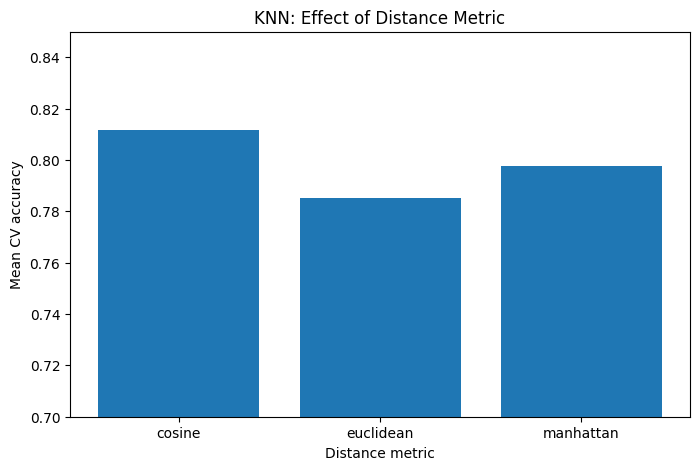

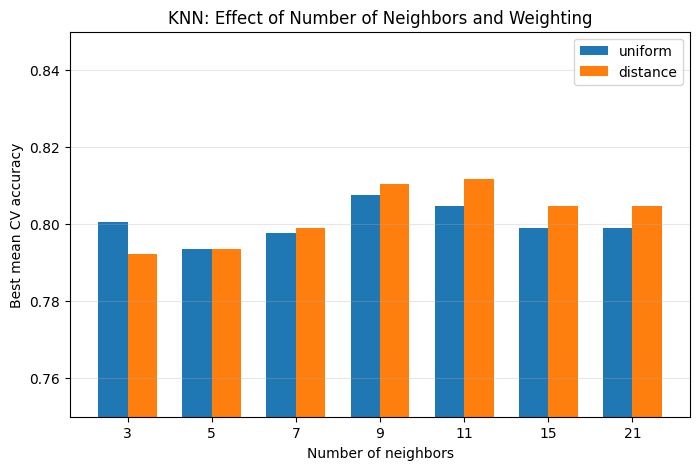

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame(cv_results)

metric_results = (
    results
    .groupby("param_metric")["mean_test_score"]
    .max()
)

plt.figure(figsize=(8, 5))
plt.bar(
    metric_results.index,
    metric_results.values
)
plt.xlabel("Distance metric")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: Effect of Distance Metric")
plt.ylim(0.7, 0.85)
plt.show()

neighbor_results = (
    results
    .groupby(["param_n_neighbors", "param_weights"])["mean_test_score"]
    .max()
    .reset_index()
)

plt.figure(figsize=(8, 5))

neighbors = sorted(neighbor_results["param_n_neighbors"].unique())
x = np.arange(len(neighbors))
width = 0.35

for i, weights in enumerate(["uniform", "distance"]):
    data = (
        neighbor_results[
            neighbor_results["param_weights"] == weights
        ]
        .set_index("param_n_neighbors")
    )

    plt.bar(
        x + (i - 0.5) * width,
        [data.loc[n, "mean_test_score"] for n in neighbors],
        width=width,
        label=weights
    )

plt.xticks(x, neighbors)
plt.xlabel("Number of neighbors")
plt.ylabel("Best mean CV accuracy")
plt.title("KNN: Effect of Number of Neighbors and Weighting")
plt.legend()
plt.ylim(0.75, 0.85)
plt.grid(axis="y", alpha=0.3)

plt.show()

So as we can see, there are some key observations:
1) So cosine performed best, suggesting that overall similarity between passenger profiles (linked featues) is more useful than absolute distance between feature differences.
2) 11 neighbors provided the best balance, 9 was pretty good but fewer neighbors lacked information. Also distance was generally a better choice - it removed an impact of the least similar set of features. Furthermore, more neighbors likely introduced some noise and irrelevant passengers. Distance weighting further reduced the influence of distant neighbors.

### XGBoost

Let's see how the boosted trees will do:

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=67,
    eval_metric="logloss"
)

xgb_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=folds,
    scoring="accuracy"
)

print("XGBoost Evaluation Results:")
print_evaluation_results(xgb_scores)

XGBoost Evaluation Results:
Mean accuracy: 0.8020
Standard deviation: 0.0350


XGBoost achieves 80.2% accuracy with a relatively low spread, already performing close to the fine-tuned KNN. This suggests that boosted trees may be a better fit for this dataset than KNN, but we will verify this after hyperparameter tuning.

#### Hyperpamaters

Let's find the best-performing hyperparameter combination:

In [10]:
from xgboost import XGBClassifier
from model_training.common import run_hyperparameter_tuning
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.005, 0.01, 0.03, 0.1, 0.2, 0.3],
    "max_depth": [3, 4, 5],
    "min_child_weight": [0, 1, 3, 5]
}


best_model, best_params, best_score, cv_results = run_hyperparameter_tuning(
    XGBClassifier(
        random_state=67,
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=1
    ),
    param_grid,
    X_train,
    y_train,
    folds
)


print("XGBoost Hyperparameter Tuning Results:")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

print("Score on test set:", best_model.score(X_test, y_test))

XGBoost Hyperparameter Tuning Results:
Best parameters: {'learning_rate': 0.005, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200}
Best cross-validation score: 0.8441
Score on test set: 0.8212290502793296


The model achieved 84.4% cross-validation accuracy and 82.1% on the test set, so better than KNN and dummy.
Let's see the hyperparameters on a chart:

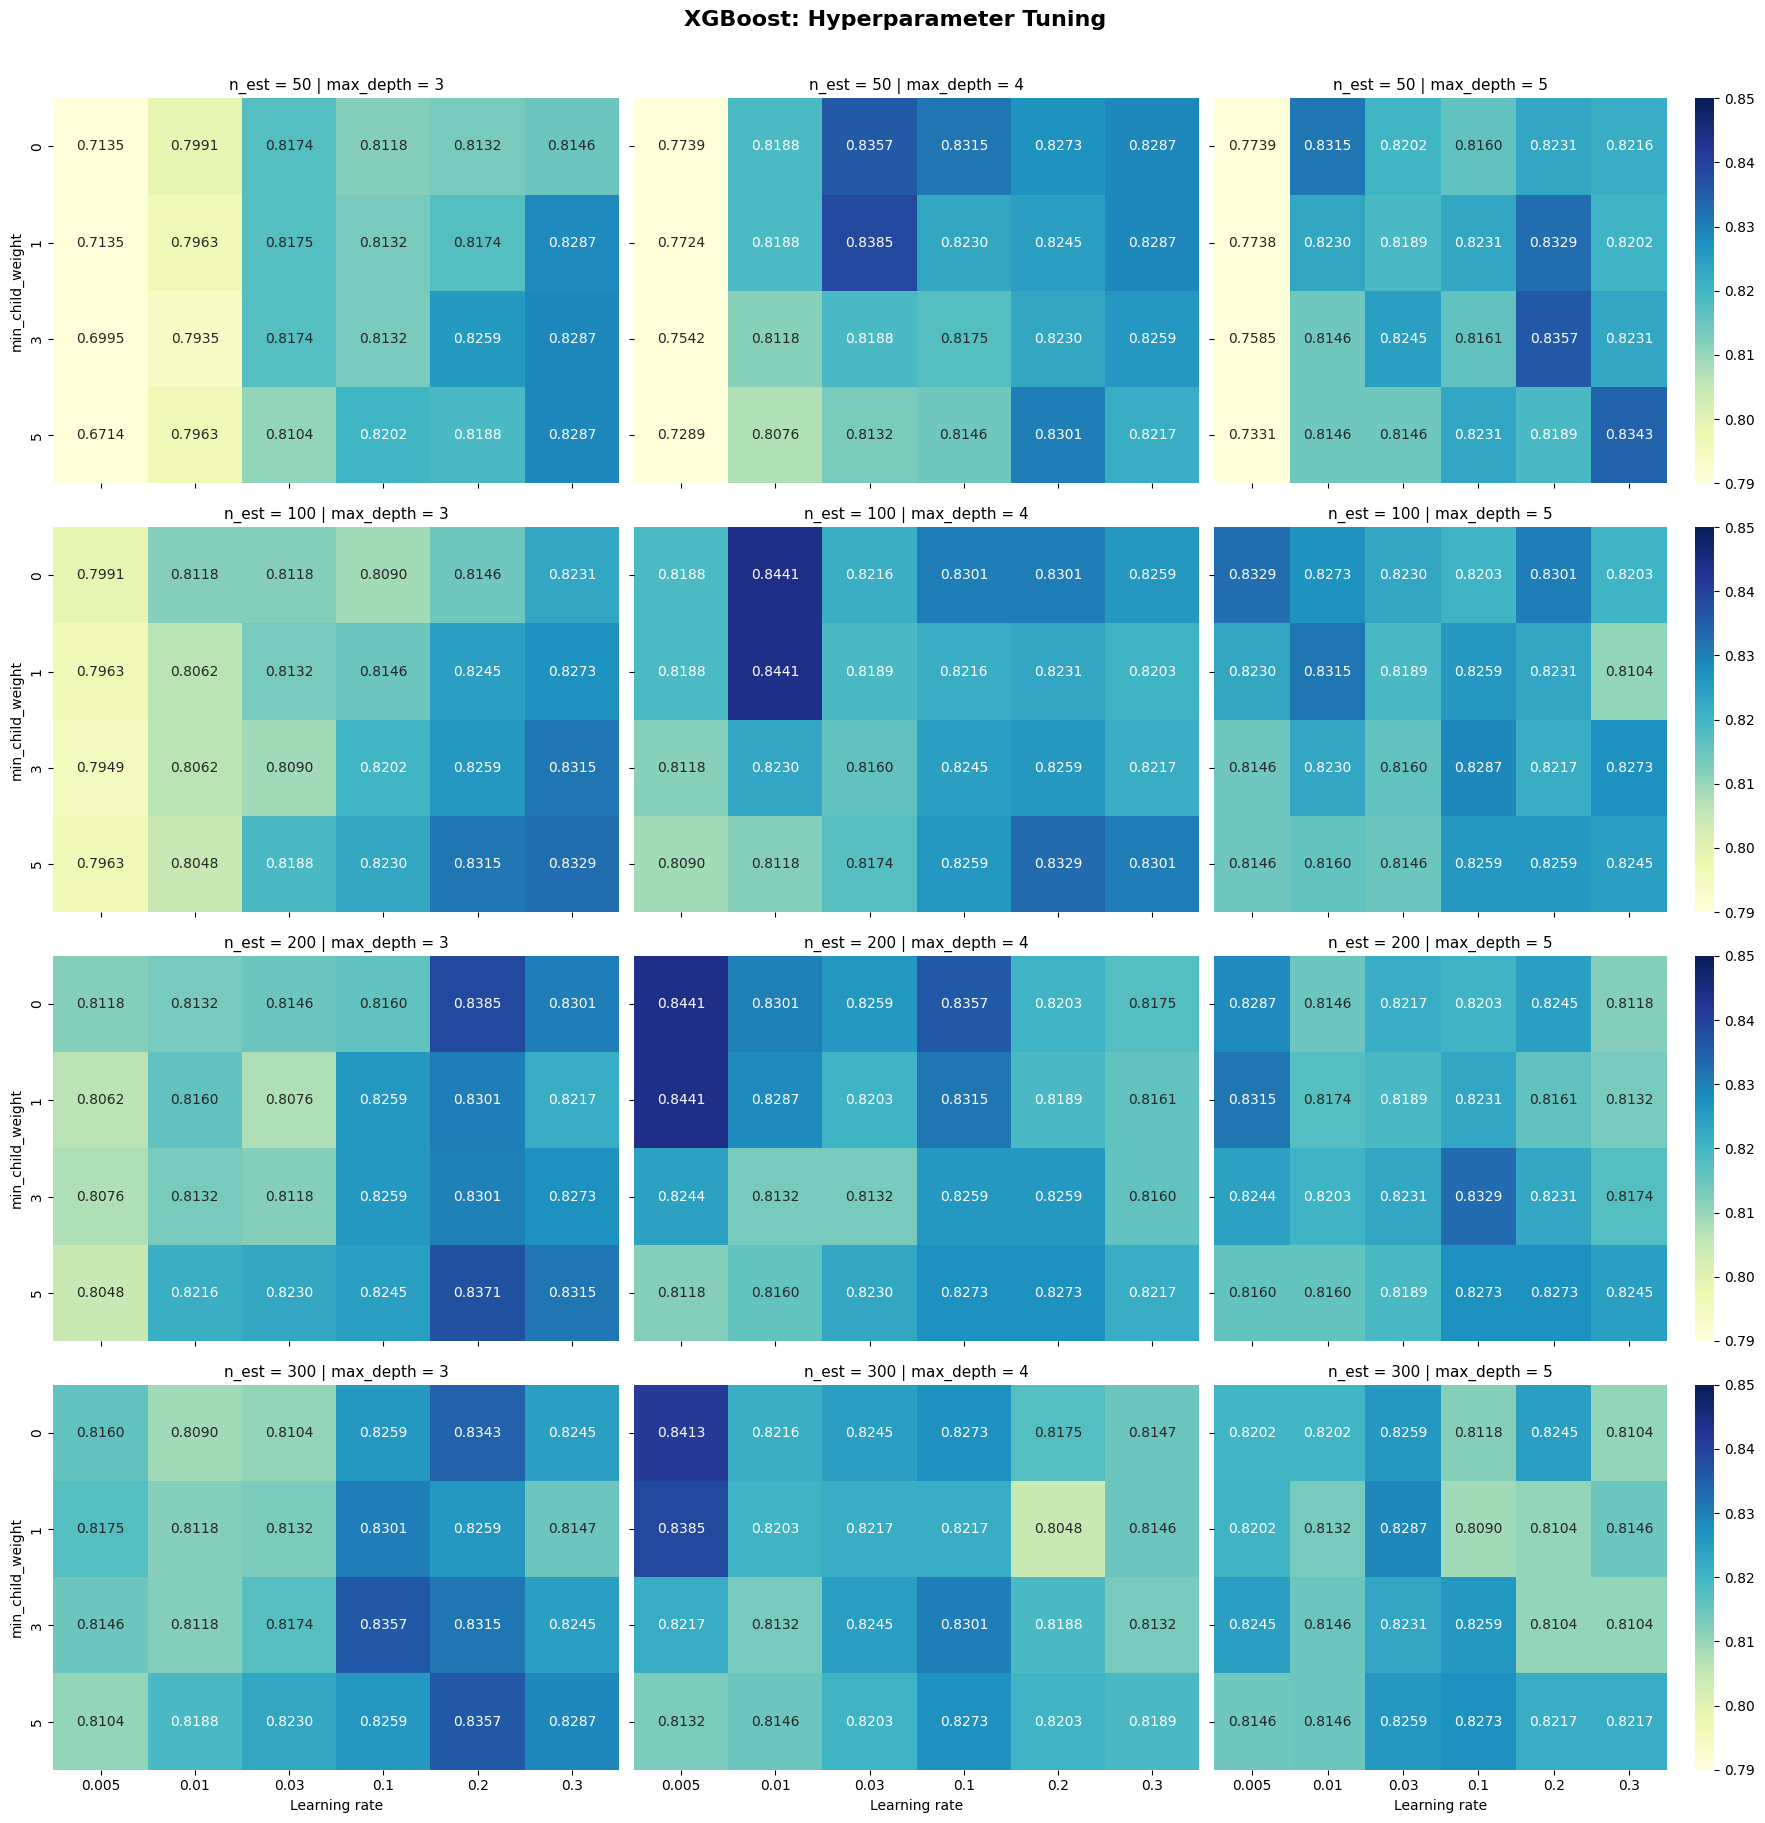

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

results = pd.DataFrame(cv_results)

max_depths = sorted(results["param_max_depth"].unique())
n_estimators_list = sorted(results["param_n_estimators"].unique())

fig, axes = plt.subplots(
    len(n_estimators_list),
    len(max_depths),
    figsize=(18, 4.5 * len(n_estimators_list)),
    sharex=True,
    sharey=True,
)

if len(n_estimators_list) == 1 and len(max_depths) == 1:
    axes = np.array([[axes]])
elif len(n_estimators_list) == 1:
    axes = axes[np.newaxis, :]
elif len(max_depths) == 1:
    axes = axes[:, np.newaxis]

for i, n_est in enumerate(n_estimators_list):
    for j, depth in enumerate(max_depths):
        ax = axes[i, j]

        data = results[
            (results["param_max_depth"] == depth)
            & (results["param_n_estimators"] == n_est)
        ]

        if data.empty:
            ax.set_visible(False)
            continue

        heatmap_data = data.pivot(
            index="param_min_child_weight",
            columns="param_learning_rate",
            values="mean_test_score",
        )

        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".4f",
            ax=ax,
            cmap="YlGnBu",
            vmin=0.79,
            vmax=0.85,
            cbar=(j == len(max_depths) - 1),
        )

        ax.set_title(f"n_est = {n_est} | max_depth = {depth}", fontsize=11)

        if i == len(n_estimators_list) - 1:
            ax.set_xlabel("Learning rate")
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel("min_child_weight")
        else:
            ax.set_ylabel("")

plt.suptitle(
    "XGBoost: Hyperparameter Tuning", y=1.01, fontsize=16, fontweight="bold"
)
plt.tight_layout()
plt.show()

Ok let's compare top alternatives:

In [12]:
import pandas as pd
from xgboost import XGBClassifier
from model_training.common import compare_candidates

candidates = [
    {
        "Candidate": "Candidate 1 (Best score)",
        "n_estimators": 100,
        "learning_rate": 0.01,
        "max_depth": 4,
        "min_child_weight": 1,
    },
    {
        "Candidate": "Candidate 2 (Slow lr)",
        "n_estimators": 200,
        "learning_rate": 0.005,
        "max_depth": 4,
        "min_child_weight": 1,
    },
    {
        "Candidate": "Candidate 3 (bigger lr and min_cw and n_est)",
        "n_estimators": 300,
        "learning_rate": 0.2,
        "max_depth":3,
        "min_child_weight": 5,
    },
    {
        "Candidate": "Candidate 4 (Low n_est)",
        "n_estimators": 50,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 1,
    }
]

compare_candidates(candidates, X_train, y_train, X_test, y_test)


,Candidate,n_estimators,learning_rate,max_depth,min_child_weight,Train Score,Test Score,Gap (Train - Test)
0,Candidate 1 (Best score),100,0.010,4,1,0.8624,0.8212,0.0411
1,Candidate 2 (Slow lr),200,0.005,4,1,0.8624,0.8212,0.0411
3,Candidate 4 (Low n_est),50,0.030,4,1,0.8652,0.8212,0.0439
2,Candidate 3 (bigger lr and min_cw and n_est),300,0.200,3,5,0.9242,0.7709,0.1532


- Candidate 1 performed in the same way as 2 (product of lr and n_est is the same). As seen having learning rate and complexity a little bit higher instantly makes it overfitted.
- Also depth of 4 was the best, the ones with lower were too simple, the one with bigger were too complex.
- Low learning rate also prevented from overfitting.
- Low min_child_weight was low, but other params were already preventing from overgitting. Min_child_weight of bigger values were too general and didn't match well.

